In [1]:
import numpy as np
import h5py
import cortex
from textgrid import TextGrid
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
import torch

/home/nquazi/miniconda3/envs/xaqlab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Loading fMRI data
After downloading the data from the box folder, use the cells below to load the fMRI data and the text grids. Note that you also need to download two python scripts and place them on the same directory that this notebook is in.

In [2]:
data_dir = '.' # set this to the directory you placed the data in

data_file_template = data_dir + '/{}.hf5'
text_grid_template = data_dir + '/{}.TextGrid'

training_stories = ['alternateithicatom','avatar','legacy','odetostepfather','souls']
                    # 'myfirstdaywiththeyankees', 'naked', 'life', 'undertheinfluence']
test_stories = ['wheretheressmoke']

all_stories = training_stories + test_stories

# load fMRI data, which is nTRs * nVoxels for each story
all_data = dict()
for story in all_stories:
    with h5py.File(data_file_template.format(story), 'r') as hf:
        all_data[story] = hf['data'][:]
        print('story {}: \t{} TRs\t {} voxels'.format(story, all_data[story].shape[0], 
                                                            all_data[story].shape[1]))


story alternateithicatom: 	343 TRs	 94251 voxels
story avatar: 	367 TRs	 94251 voxels
story legacy: 	400 TRs	 94251 voxels
story odetostepfather: 	404 TRs	 94251 voxels
story souls: 	355 TRs	 94251 voxels
story wheretheressmoke: 	291 TRs	 94251 voxels


In [3]:
# loading textgrids
words = dict()
word_onset = dict()
word_end = dict()
removed_time = 10

for story in all_stories:
    text_grid = TextGrid(open(text_grid_template.format(story)).read())
    simple_transcript = text_grid.tiers[1].make_simple_transcript()
    print('story {}: \t{} words'.format(story, len(simple_transcript)))
    words[story] = [t[2] if t[2] not in ['', ' '] else 'sp' for t in simple_transcript] # handles edge case of empty word
    word_onset[story] = np.array([float(t[0]) for t in simple_transcript]) - removed_time
    word_end[story] = np.array([float(t[1]) for t in simple_transcript])- removed_time

### example
print('first five words of souls:', words['souls'][:5])
print('onset times:', word_onset['souls'][:5])
print('end times:', word_end['souls'][:5])

story alternateithicatom: 	2681 words
story avatar: 	1952 words
story legacy: 	2568 words
story odetostepfather: 	3300 words
story souls: 	2481 words
story wheretheressmoke: 	2308 words
first five words of souls: ['sp', 'SO', 'A', 'LOT', 'OF']
onset times: [-9.98752834 -7.1739229  -6.65144813 -6.28021532 -6.01725875]
end times: [-7.1739229  -6.65144813 -6.28021532 -6.01725875 -5.89351448]


In [5]:
for story in all_stories:
    print(all_data[story].shape[0]*2 , word_onset[story][-1])

686 687.205540420267
734 735.957142857
800 805.3219846335285
808 807.6574003622386
710 712.270975057
582 582.515873016


#### Printing the transcript for a story 

Note that there are additional symbols ('sp','br') which correspond to non-word events (such as a breath), and you might want to remove them from consideration when building language features.

In [6]:
print( ' '.join(words['alternateithicatom'][:100]))

sp THERE'RE SOME SCIENTISTS WHO SAY THAT THE UNIVERSE THAT WE INHABIT sp {BR} sp IS NOT THE ONLY UNIVERSE sp THERE IS sp {BR} THERE ARE ALTERNATE UNIVERSES sp {BR} THEY SAY THAT THESE UNIVERSES ARISE sp {BR} sp FROM THE SUB ATOMIC sp REALM OF sp QUANTUM PHYSICS HERE'S HOW THEY SAY IT WORKS sp {BR} sp EVERY TIME sp A QUANTUM EVENT HAPPENS sp {BR} IT PRODUCES sp ALL OF ITS POSSIBLE RESULTS sp THIS IS LIKE SAYING IF YOU sp FLIP A COIN sp {BR} sp IT COMES UP HEADS sp BUT IT ALSO COMES UP


### Create word level and sequence level features

Here, you can choose the language model you want to generate single word (non-contextualized) embeddings, and embeddings for the word in context. When doing such an analysis need to decide on:
- the language model 
- how to construct the embedding
    - if using a causal model (such as gpt), each word embedding has only words from the past, which is consistent with our hypothesis
    - if using a non-causal model such as bert, use it by repeatedly using each word as the last word and extracting the embeddings then
    - if the model is stateful, we can input words one at a time and read the embeddings (infinite context)
    - alternatively, we can input for each word a sentence that ends with that word (can be fixed length or from the start of the sentence)
- which layers to extract the embeddings from

Early work in this domain used a variety of these options ([Wehbe 2014](https://aclanthology.org/D14-1030.pdf), [Jain 2018](https://proceedings.neurips.cc/paper_files/paper/2018/hash/f471223d1a1614b58a7dc45c9d01df19-Abstract.html), [Toneva 2019](https://proceedings.neurips.cc/paper/2019/file/749a8e6c231831ef7756db230b4359c8-Paper.pdf)).
In the example below, we use an example bert model from huggingface, for each word, we will incorporate the past `n_words_in_context=20` words into the context for each word, we extract single word embeddings and last layer embedding (for this model, the last layer is layer 12). 

You can choose the model you want, and you will need to extract embeddings at the single word level and at another level (the example below chooses the last layer but the early papers above suggest the middle layers can do better for fMRI). 



In [4]:
# optional to use this code, you can also use another language model

import time

n_words_in_context = 20 
layer = 12
size_embedding = 768 # this is specific to the model you choose

# Load model and tokenizer
model_name = "bert-base-uncased"  # Change to your desired model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# function to get single token embeddings efficiently, used in the loop below
embedding_layer = model.get_input_embeddings()

single_word = dict()
sequence = dict()

for story in all_stories:
    # Tokenize all words in one batch (faster!), this returns a list of lists of tokens
    # one for each word
    tokenized_output = tokenizer(words[story], add_special_tokens=False)['input_ids']

    # prepare matrices to store embeddings
    single_word[story] = np.zeros((len(words[story]), size_embedding))
    sequence[story] = np.zeros((len(words[story]), size_embedding))
    
    with torch.no_grad():
        tic = time.time()
        for iword in np.arange(len(tokenized_output)):
            # construct a list of the token that we are considering for this word (starting from n_words_in_context ago)
            i_start = np.max([0,iword-n_words_in_context]) # which word to start from
            if iword>10:
                sequence_tokens = tokenized_output[i_start:iword+1] # list of the tokens of the words in context
                sequence_tokens_flat = [item for sublist in sequence_tokens for item in sublist] # flat list of tokens
                inputs = {
                        "input_ids": torch.tensor([sequence_tokens_flat] ),  # Add batch dimension
                        "attention_mask": torch.ones((1, len(sequence_tokens_flat)))  # Ensure attention mask
                        }
                
                # run though model
                outputs = model(**inputs, output_hidden_states=True)
    
                # extract sequence embeddings at given layer
                sequence_embeddings = outputs.hidden_states[layer].squeeze()[-1] # pick layer and last word
                sequence[story][iword] = sequence_embeddings.detach().cpu().numpy()
                
            # extract single word embeddings as average of word tokens (often there is only one token but this works anyways)
            single_word[story][iword] = embedding_layer(torch.tensor(tokenized_output[iword])).detach().cpu().numpy().mean(0)

            # estimate time left
            if iword%1000==100:
                print('story: {}, time remaining: {} seconds'.format(story, (time.time()-tic)/(iword+1)* (len(tokenized_output)-iword-1)))
            

story: alternateithicatom, time remaining: 43.262152341332765 seconds
story: alternateithicatom, time remaining: 27.22558713630586 seconds
story: alternateithicatom, time remaining: 9.826382412790174 seconds
story: avatar, time remaining: 29.055356825932417 seconds
story: avatar, time remaining: 14.3362473103266 seconds
story: legacy, time remaining: 38.94939883392637 seconds
story: legacy, time remaining: 23.35373686055072 seconds
story: legacy, time remaining: 7.845333626927336 seconds
story: odetostepfather, time remaining: 47.030471650680695 seconds
story: odetostepfather, time remaining: 38.01061325696898 seconds
story: odetostepfather, time remaining: 20.616605351732662 seconds


KeyboardInterrupt: 

In [ ]:
# optional: Save to a compressed `.npz` file (efficient for storage), so you don't have to keep running things
# np.savez_compressed("single_word.npz", **single_word)
# np.savez_compressed("sequence.npz", **sequence)
# optional: to load:
# size_embedding = 768
# single_word = np.load("single_word.npz")
# sequence = np.load("sequence.npz")

*Note*: if you want to reduce the dimensionality of your embeddings, this is a good place to do so (see the model fitting section).

#### Aligning to TR timing

The next step is to align the time of the word embeddings to the time of fMRI. For each story with nTRs time points, we want to build a matrix that is nTRs * size of embeddings space that contains the average semantic space at that time. In the [speech model tutorial](https://github.com/HuthLab/speechmodeltutorial), this is done with Laczos filtering.

Implement below your method of choice for making this matrix. You can also use a simple averaging ( for each TR, average the embeddings of all the words that start in that TR).


In [ ]:
# this parameter is from the dataset, how long it took to get each brain scan, in seconds:
TR_length = 2

story = 'alternateithicatom'

## construct TR times vector
nTRs = all_data[story].shape[0]
TR_times = np.arange(nTRs)*TR_length 

## make a plot to see the word onset times & features with respect to the TR onset time
plt.figure(figsize=(12,4))
plt.stem(word_onset[story], single_word[story][:,1],'k',label = 'feature 1 value')
plt.stem(TR_times,np.ones(nTRs)*0.1,'x',label = 'TR onset')
plt.legend()
plt.xticks(word_onset[story][40:80],words[story][40:80],rotation=90)
plt.xlim([0,10])

In [ ]:
single_word_TRs = dict()
sequence_TRs = dict()

## now write a function to create a nTRs * size_embedding matrix for each story



### Create delayed features

As we saw in the paper discussed in class ([Huth 2016](https://www.nature.com/articles/nature17637) and [Wehbe 2014b](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0112575), the fMRI response is capturing events from the previous time steps. A simple way to capture this is to delay the feature spaces by some numbers and concatenate all the delays. You can see in the speech model tutorial how this is done as well.

1- Implement below  a function called `delay_mat` that does the time delay and concatenation that takes as input a matrix and a list of delays and returns a delayed and concatenated matrix. Make sure that the features are delayed with respect to the data by testing things. U

*Note that you if you use the `np.roll` function you absolutely have to specify the axis on which to roll, otherwise it does an element wise roll. You can also implement a simple delay function.*

2- Use the `delay_mat` function it with delays [1,2,3,4] (corresponding to the past 8 seconds). After producing the required matrices, produce a plot of the relevant parts of one matrix from one story to show the delayed features (for example a `plt.imshow` plot showing only a few chosen by hand columns and 10 rows that shows the delayed relationship). Explain in a few lines why the plot shows the delay.

In [ ]:

### implement delay_mat below 
def delay_mat(stim, delays, circpad=False):
    """Creates non-interpolated concatenated delayed versions of [stim] with␣
    ↪the given [delays]
    (in samples).
    If [circpad], instead of being padded with zeros, [stim] will be circularly␣
    ↪shifted.
    """
    nt,ndim = stim.shape
    dstims = []
    for di,d in enumerate(delays):
        dstim = np.zeros((nt, ndim))
        if d<0: ## negative delay
            dstim[:d,:] = stim[-d:,:]
            if circpad:
                dstim[d:,:] = stim[:-d,:]
        elif d>0:
            dstim[d:,:] = stim[:-d,:]
            if circpad:
                dstim[:d,:] = stim[-d:,:]
        else: ## d==0
            dstim = stim.copy()
        dstims.append(dstim)
    return np.hstack(dstims)


In [ ]:
delays = np.arange(1,5)
single_word_TRs_delayed = dict([(s,delay_mat(v,delays)) for s,v in single_word_TRs.items()])
sequence_TRs_delayed = dict([(s,delay_mat(v,delays)) for s,v in sequence_TRs.items()])


### make the plot below


#### Your Answer
...



#### Prepare the fMRI data

We will use the pycortex package to plot the data, it has very powerful visualizations. Let's look at an actual frame from the data.

To do so, we need to create a pycortex volume data structure. Please see the [documentation](https://gallantlab.org/pycortex/) for more information.

At a high level:
- we have data or results we want to plot. They are in the voxel space.
- the data corresponds to a subject (`surface = 'UTS02'` in this case) for which we have an inflated surface
- there is a way to map the voxels onto that surface. This is a matrix which is store in the pycortex filestore along with the other needed information. In this case, we should use `transform = 'UTS02_auto'`.

**Make sure you have followed the installation instructions to have `UTS02` in your pycortex store.**

Once we have the volume data, we can use different approaches for making visualization. The most powerful approach is to make a pycortex webviewer (easiest if you work locally). Another approach is to create flatmaps.

In [ ]:
surface = 'UTS02'
transform = 'UTS02_auto'
vmin = -2
vmax = 2
cmap = 'RdBu_r'

vol = cortex.Volume(all_data['avatar'][100], subject=surface, xfmname=transform, vmin = vmin, vmax = vmax,cmap=cmap)

In [ ]:
# webviewer command -- optional
cortex.webshow(vol)
## when you open this, see what happens when you click 'i' or 'f' or 'r'. Try the commands in the bar.

In [ ]:
cortex.quickflat.make_figure(vol);

The data appears to be zscored. The hand drawn boundaries correspond to known regions that are localized with a functional localizer. Let's change the colormap.

In [ ]:
surface = 'UTS02'
transform = 'UTS02_auto'
vmin = -2
vmax = 2
cmap = 'Reds'

vol = cortex.Volume(all_data['avatar'][100], subject=surface, xfmname=transform, vmin = vmin, vmax = vmax,cmap=cmap)
cortex.quickflat.make_figure(vol);

`RdBu_r` is a diverging colormap while `Reds` is a sequencial colormap (see more [here](https://matplotlib.org/stable/users/explain/colors/colormaps.html)). Think of the range of values and their meaning (what does -2, 0 or 2 represent). Which is a more appropriate colormap for plotting the zscored activity?

#### Answer:
...

The `wheretheressmoke` story is actually the average of 5 zscored repeats of the same story (zscored data has a variance of 1 by definition). Therefore it's variance is not 1. Plot below the variance for each voxel for that story on a flatmap. 

1 - Set `vmin = 0` and `vmax=1`. Should you choose a divergent or a sequential colomap and why? 

2 - Some regions have higher variance than others. Are these expected to have more signal to noise ratio or less, and why?


#### Answer:
...

In [ ]:
# your code answer:
surface = 'UTS02'
transform = 'UTS02_auto'
vmin = 0
vmax = 1
cmap = 'Reds'

vol = cortex.Volume(all_data['wheretheressmoke'].var(axis=0), subject=surface, xfmname=transform, vmin = vmin, vmax = vmax,cmap=cmap)
cortex.quickflat.make_figure(vol);

#### Preparing data for training and testing

Typically, we always zscore **each run** (i.e., in this case, each story) of data separately. In this preprocessed data, this is already done, except for the averaged test story (`wheretheressmoke`). We thus don't have to repeat it except for the test data.

Let's also plot the variance of the semantic features we have. It is also common practice to normalize those. Let's zscore each story's features  before creating the training and test matrices.

In [5]:
# load the zscore function
from scipy.stats import zscore

# using a list insures the order remains the same for the data and the features
training_data = np.vstack ([all_data[story] for story in training_stories]) 
test_data = zscore(all_data[test_stories[0]])

# training_word_emb =  np.vstack ([zscore( single_word_TRs_delayed [story]) for story in training_stories])
# training_sequence_emb =  np.vstack ([zscore( sequence_TRs_delayed [story]) for story in training_stories])
#
# test_word_emb = zscore(single_word_TRs_delayed[test_stories[0]])
# test_sequence_emb = zscore(sequence_TRs_delayed[test_stories[0]])


### Training the model

Here, you have to use a cross-validated ridge regression function where you choose a different lambda parameter for each output (each voxel). Note that most packages do not have this functionality (for example `RidgeCV` from `sklearn` does allow you to do cross-validation but choose a global regularization parameter for all outputs).

You are welcome to write you own function or to use the one provided in the box folder as below. You can also use the provided bootstrap_ridge function in the speech model tutorial. Make sure to return the weights as well as the chosen regularization parameters. Note that the provided function assumes you are working with zscored inputs and outputs.

Optional: if the regression code takes a long time (because you need to invert a large matrix), you can consider other GPU implementations (example [clip2brain](https://github.com/ariaaay/clip2brain/blob/main/src/encodingmodel/ridge.py) and [himalaya](https://github.com/gallantlab/himalaya) which has a kernel ridge formulation appropriate for matrices that are wider than they are tall. For a simple solution for the homework, you can also do PCA and reduce the dimensionality of the feature space (e.g. to 40 dimensions). This is not as accurate as keeping the entire feature space. If you choose this option, a good place to do it is after you generate the words features. Remove the mean from all the runs. Concatenate all the run matrix and estimate the PCs. Then use the PCs on the the original de-meaned runs.

In [ ]:
from ridge_tools import cross_val_ridge

In [ ]:
# optional to change the function
weights_word, lambda_word = cross_val_ridge( training_word_emb, training_data, n_splits=4,
                                            lambdas=np.array([10**i for i in range(-6, 10)]), method="ridge_sk")

In [ ]:
# optional to change the function
weights_sequence, lambda_sequence = cross_val_ridge( training_sequence_emb, training_data, n_splits=4,
                                            lambdas=np.array([10**i for i in range(-6, 10)]), method="ridge_sk")

Use the learned coefficients to compute prediction performance (using pearson correlation as a metric) on the training dataset for the word and sequence embedding. Make the following flatmap plots:
- plot of the prediction performance per voxel for the word model, pick vmin = -0.5 and vmax = 0.5 and a divergent colormap. Name the resulting volume structure `vol_word`.
- plot of the lambda parameters picked by cross-validation. Use a log scale (take `np.log10` of the lambda value). Pick an appropriate vmin, vmax and colormap.

How do the patterns of high accuracy / low regularization parameter compare? You can see [this paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC8317475/) for more discussion.

In [ ]:
from ridge_tools import corr ## can use this function to compute pearson correlation for each column 
test_accuracy_word = corr(test_data, np.dot(test_word_emb, weights_word)) # correlation between real data and predictions

## make plots
surface = 'UTS02'
transform = 'UTS02_auto'
vmin = -0.5
vmax = 0.5
cmap = 'RdBu_r'

vol_word = cortex.Volume(test_accuracy_word, subject=surface, xfmname=transform, vmin = vmin, vmax = vmax,cmap=cmap)
cortex.quickflat.make_figure(vol_word);

Create a histogram of the voxel accuracy, note how there seems to be a symmetric wide null distribution around 0 as well as right tail with a set of voxels that appear to have a correlation higher than chance. 

In [ ]:
plt.hist(test_accuracy_word,100);

In [ ]:
# plot the (log 10 of the) lambda chosen for each voxel on a flatmap  

## make plots
surface = 'UTS02'
transform = 'UTS02_auto'
vmin = -6
vmax = 10
cmap = 'RdBu_r'

vol_alpha = cortex.Volume(np.log10(lambda_word), subject=surface, xfmname=transform, vmin = vmin, vmax = vmax,cmap=cmap)
cortex.quickflat.make_figure(vol_alpha);

What do you notice about the pattern of lambda and of prediction performance? Does this align with the predictions from the linked paper above?

#### Answer:

...

#### Sequence model
Compute the performance for the sequence model and plot it on a flatmap. Name the resulting volume structure `vol_sequence`.

In [ ]:
test_accuracy_sequence = corr(test_data, np.dot(test_sequence_emb, weights_sequence)) # correlation between real data and predictions

## make plots
surface = 'UTS02'
transform = 'UTS02_auto'
vmin = -0.5
vmax = 0.5
cmap = 'RdBu_r'

vol_sequence = cortex.Volume(test_accuracy_sequence, subject=surface, xfmname=transform, vmin = vmin, vmax = vmax,cmap=cmap)
cortex.quickflat.make_figure(vol_sequence);

### Comparing the two models on the same flatmap

In pycortex, it is possible to do a 2D flatmap that shows two types of information at the same time. Consider the two examples below:

- RdBu_r_alpha

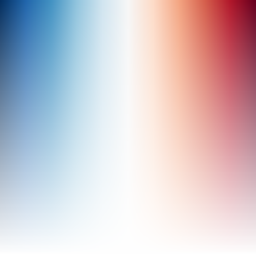

This colormap is good for showing the value of a statistic (on the x-axis) while using another statistic (on the y-axis) to control the visibility of the first (in this case the transparency). For example, the first statistic can be the prediction performance of a model, and the second can be the explainable variance, hiding the values when the explainable variance is small.

- PU_RdBu_covar_alpha

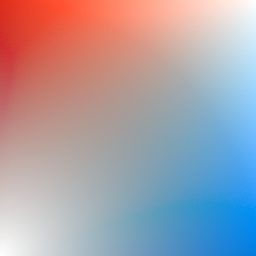

(The lower left corner is transparent). This colormap is good for showing how two similar statistics (e.g. the performance from two feature spaces). It will be blue when the first is high, red when the second is high, white when both are high and transparent when none is high.

Note: this is a perceptually uniform colormap, read more [here](https://matplotlib.org/stable/users/explain/colors/colormaps.html).

Pycortex contains a set of [colormaps](https://github.com/gallantlab/pycortex/tree/main/filestore/colormaps) that you can explore in the downloaded directory on your computer. The best is to produce a pycortex viewer: you can put the two volumes above in a dictionary and open a webviewer with that dictionary, once started, you can drag one volume on top of the other and that creates a 2D viewer. You can then choose which colormap to use by clicking on the colormap. Another way to produce 2D volumes and view them is shown below.



In [ ]:
vol2D = cortex.Volume2D(vol_word, vol_sequence)
# This inherits the vmin and vmax from the volume. you can also set them again as below:
vol2D = cortex.Volume2D(vol_word, vol_sequence, vmin=0,vmax=0.3, vmin2=0,vmax2=0.3, cmap = 'PU_RdBu_covar_alpha')

In [ ]:
cortex.quickflat.make_figure(vol2D, with_curvature=True);

Note that the first volume specified will get the color on the x-axis. Describe the results you obtain. What regions prefer word information and what regions prefer longer sequences?  Do you results align with [Jain 2018](https://proceedings.neurips.cc/paper_files/paper/2018/hash/f471223d1a1614b58a7dc45c9d01df19-Abstract.html)?

#### Answer

...

### Collaboration Policy

After you have completed all other components of this assignment, report your answers to the collaboration policy questions detailed in the Academic Integrity Policies found [here](http://www.cs.cmu.edu/~mgormley/courses/10601bd-f18/about.html#7-academic-integrity-policies).

1. **Did you receive any help whatsoever from anyone in solving this assignment?**  
   If so, include full details including names of people who helped you and the exact nature of help you received.

#### Answer:
...

2. **Did you give any help whatsoever to anyone in solving this assignment?**  
If so, include full details including names of people you helped and the exact nature of help you offered.

#### Answer:
...


3. **Did you find or come across code that implements any part of this assignment?**  
If so, include full details including the source of the code and how you used it in the assignment.

#### Answer:
...